In [2]:
## conda activate gift_spatial

import matplotlib.pyplot as plt
import matplotlib

from spatial_utils import plot_celltype_specific_probes_spatial_multi_cellline, read_dual_probe_data, read_gapfill_data, read_genotype_annotations

matplotlib.rcParams['pdf.fonttype'] = 42

import sys
sys.path.append('../../figure_CL_proof_of_concept/code/')
import utils_00 as gf_utils
large_data_dir = gf_utils.large_data_dir

# plt.style.use("pretty-plot")

/data1/lareauc/users/blattms/miniconda3/envs/gift_spatial/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
data_path = f"{large_data_dir}gf_CL_VisiumHD/"
# Load data:
gapfill_sdata = read_gapfill_data(gf_adata_path = f"{data_path}GapFill_CellLineMix_Visium_GF.h5ad", WTA_dir = f"{data_path}GapFill_WTA.zarr")
annotated_genotypes, celltype_genotypes, wt_alleles, alt_alleles = read_genotype_annotations()

/home/blattms1/projects/gapfill/gift_paper_reproducibility/1_figure_CL_proof_of_concept/code/spatial_utils.py:194: UserWarning: SpatialData is not stored in the most current format. If you want to use Zarr v3, please write the store to a new location using `sdata.write()`.
  gapfill_wta = read_zarr(WTA_dir)


Info: if genotyping takes too long, consider setting cores > 1.


Genotyping : 100%|██████████| 159/159 [00:15<00:00, 10.16it/s, Probe ZNF609]                             
/data1/lareauc/users/blattms/miniconda3/envs/gift_spatial/lib/python3.12/site-packages/giftwrap/analysis/spatial.py:280: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  gf_table.uns[sd.models.TableModel.ATTRS_KEY] = wta_table.uns[sd.models.TableModel.ATTRS_KEY].copy()


Info: Calling genotypes for the binned data using the previous arguments:
flavor: basic
threshold: 0.5
cores: 1
Info: if genotyping takes too long, consider setting cores > 1.


Genotyping : 100%|██████████| 159/159 [00:05<00:00, 27.29it/s, Probe ZNF609]                             
/data1/lareauc/users/blattms/miniconda3/envs/gift_spatial/lib/python3.12/site-packages/giftwrap/analysis/spatial.py:280: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  gf_table.uns[sd.models.TableModel.ATTRS_KEY] = wta_table.uns[sd.models.TableModel.ATTRS_KEY].copy()


Info: Calling genotypes for the binned data using the previous arguments:
flavor: basic
threshold: 0.5
cores: 1
Info: if genotyping takes too long, consider setting cores > 1.


Genotyping : 100%|██████████| 159/159 [00:02<00:00, 58.27it/s, Probe ZNF609]                             
/data1/lareauc/users/blattms/miniconda3/envs/gift_spatial/lib/python3.12/site-packages/giftwrap/analysis/spatial.py:280: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  gf_table.uns[sd.models.TableModel.ATTRS_KEY] = wta_table.uns[sd.models.TableModel.ATTRS_KEY].copy()



=== UMI Genotype Specificity Summary ===
Cell Line      CL-Specific UMIs  Total Specific UMIs  % Matching Genotype
--------------------------------------------------------------------------
HEL                       25741                25806                99.7%
K562                      28193                28416                99.2%
SET2                      15945                17052                93.5%
--------------------------------------------------------------------------
Grand total               71274



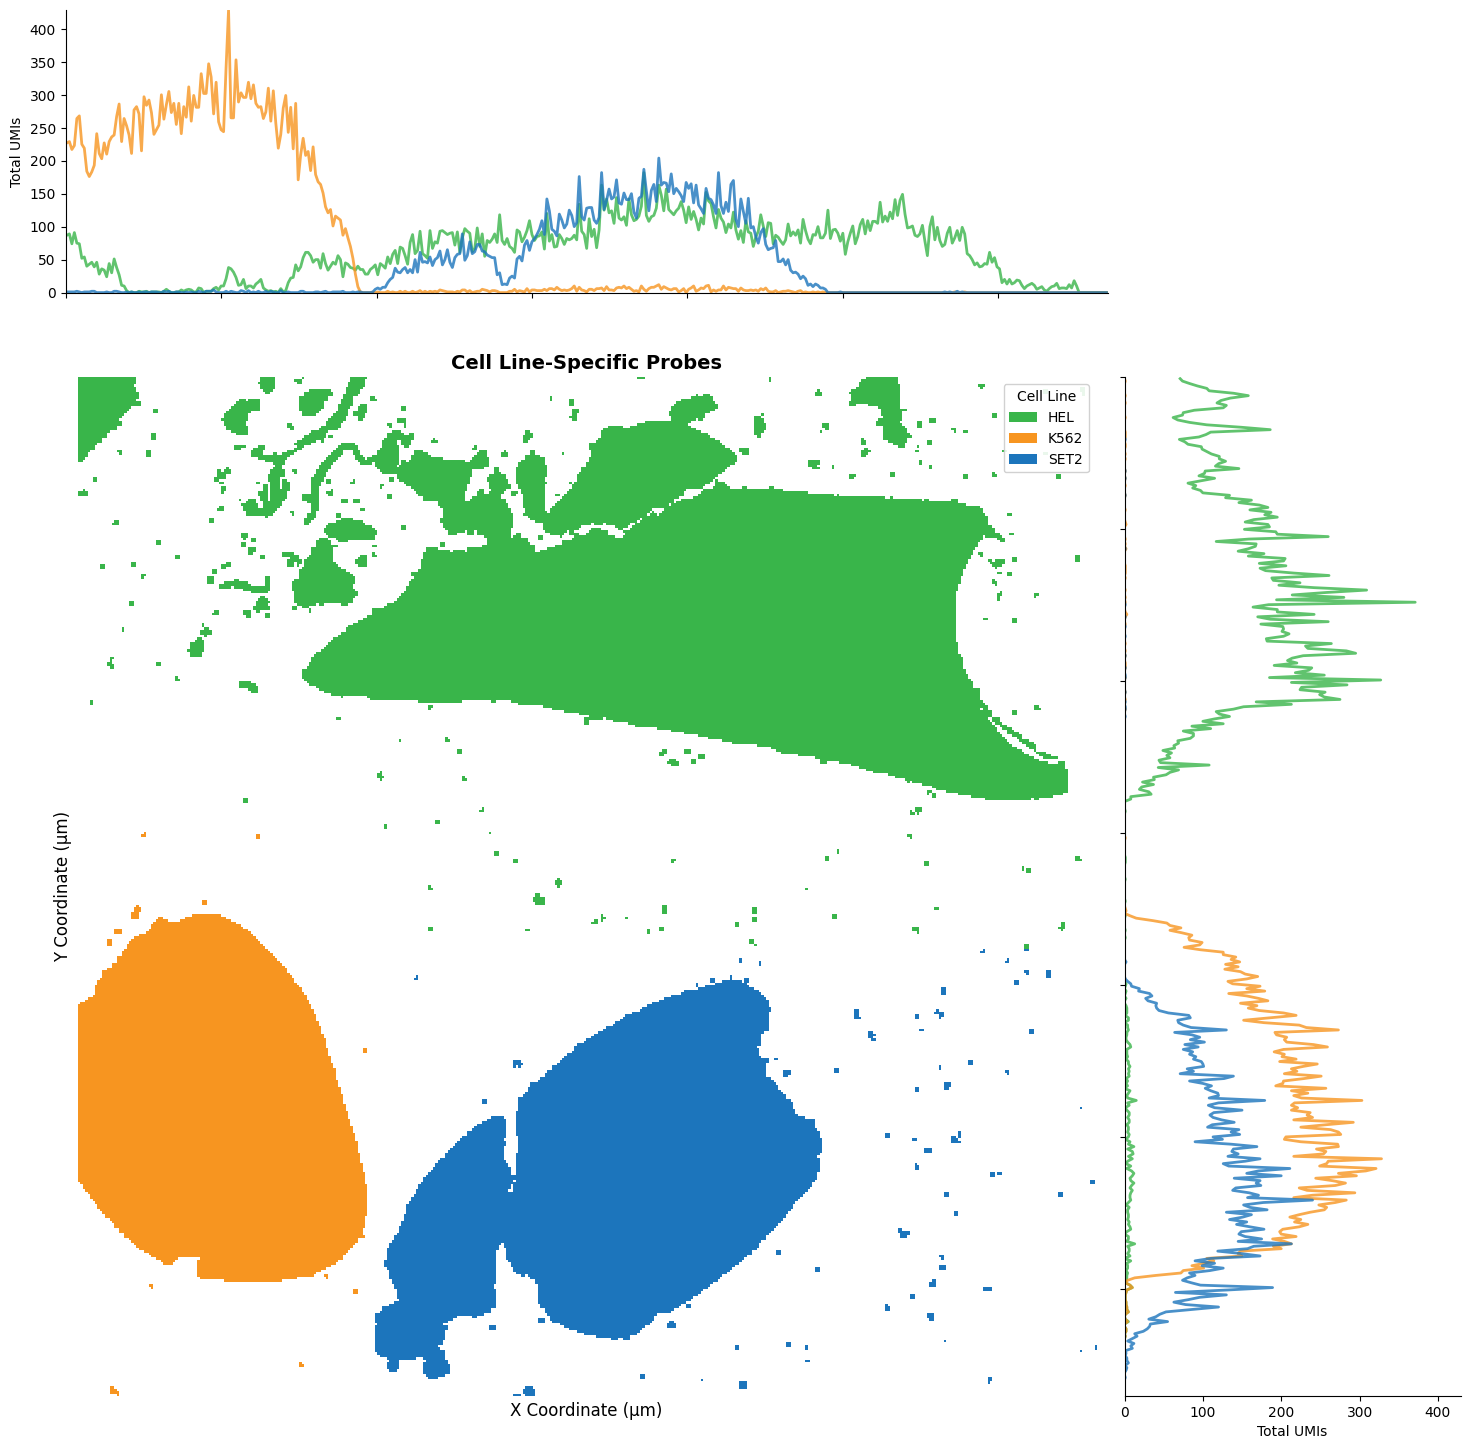

In [4]:
fig2, axes2, summary2 = plot_celltype_specific_probes_spatial_multi_cellline(
    gapfill_sdata,
    annotated_genotypes,
    celltype_genotypes,
    wt_alleles,
    alt_alleles,
    figsize=(18,18),
    include_het=True,
    color_by_celline=True,
    smooth_lines=True,
    resolution=16,
    log_scale_marginals=False  # Linear scale for marginals
)

plt.savefig('../plots/visium_dual_vs_gapfill_spatial_specificity.pdf', bbox_inches='tight')
plt.show()